In [2]:
!pip install transformers tqdm seaborn -q

In [3]:
import os
import pickle
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import (
    BertTokenizer,
    BertModel
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout
)

2026-05-27 06:58:37.769704: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779865117.970886      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779865118.028462      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779865118.495323      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779865118.495377      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779865118.495381      16 computation_placer.cc:177] computation placer alr

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using Device:", device)

Using Device: cpu


In [5]:
DATASET_PATH = "/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data"

texts = []
labels = []

for folder in os.listdir(DATASET_PATH):

    folder_path = os.path.join(DATASET_PATH, folder)

    for file in os.listdir(folder_path):

        if file.endswith(".wav"):

            parts = file.replace(".wav","").split("_")

            word = parts[1]

            emotion = parts[2]

            transcript = f"Say the word {word}"

            texts.append(transcript)

            labels.append(emotion)

print("Total Samples:", len(texts))

print(texts[0])
print(labels[0])

Total Samples: 2800
Say the word home
fear


In [6]:
le = LabelEncoder()

encoded_labels = le.fit_transform(labels)

print("Classes:")
print(le.classes_)

Classes:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']


In [7]:
tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

bert = BertModel.from_pretrained(
    'bert-base-uncased'
).to(device)

bert.eval()

print("BERT Loaded")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT Loaded


In [8]:
def extract_bert_embedding(text):

    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=64
    )

    inputs = {
        k:v.to(device)
        for k,v in inputs.items()
    }

    with torch.no_grad():

        outputs = bert(**inputs)

        embedding = outputs.pooler_output

    embedding = embedding.cpu().numpy().squeeze()

    return embedding

In [9]:
FEATURE_CACHE = "bert_features.npy"
LABEL_CACHE = "text_labels.npy"

if (
    os.path.exists(FEATURE_CACHE)
    and
    os.path.exists(LABEL_CACHE)
):

    print("Loading Cached Features...")

    X = np.load(FEATURE_CACHE)

    y = np.load(LABEL_CACHE)

else:

    print("Extracting BERT Features...")

    features = []

    for text in tqdm(texts):

        emb = extract_bert_embedding(text)

        features.append(emb)

    X = np.array(features)

    y = np.array(encoded_labels)

    np.save(FEATURE_CACHE, X)

    np.save(LABEL_CACHE, y)

print("Feature Shape:", X.shape)
print("Labels Shape:", y.shape)

Extracting BERT Features...


100%|██████████| 2800/2800 [02:15<00:00, 20.62it/s]

Feature Shape: (2800, 768)
Labels Shape: (2800,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (2240, 768)
Test Shape: (560, 768)


In [11]:
num_classes = len(le.classes_)

model = Sequential([

    Dense(
        256,
        activation='relu',
        input_shape=(768,)
    ),

    Dropout(0.3),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        num_classes,
        activation='softmax'
    )
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-27 07:01:24.255921: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 230,663 (901.03 KB)

 Trainable params: 230,663 (901.03 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=10,
    batch_size=32
)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1371 - loss: 2.0097 - val_accuracy: 0.1429 - val_loss: 1.9502
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1549 - loss: 1.9526 - val_accuracy: 0.1500 - val_loss: 1.9470
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1415 - loss: 1.9465 - val_accuracy: 0.1429 - val_loss: 1.9460
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1411 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1433 - loss: 1.9462 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1321 - loss: 1.9460 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1366 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1460 - loss: 1.9460 - val_accuracy: 0.1429 - val_loss:

In [13]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.14285714285714285

Classification Report:

              precision    recall  f1-score   support

       angry       0.00      0.00      0.00        80
     disgust       0.14      1.00      0.25        80
        fear       0.00      0.00      0.00        80
       happy       0.00      0.00      0.00        80
     neutral       0.00      0.00      0.00        80
          ps       0.00      0.00      0.00        80
         sad       0.00      0.00      0.00        80

    accuracy                           0.14       560
   macro avg       0.02      0.14      0.04       560
weighted avg       0.02      0.14      0.04       560



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


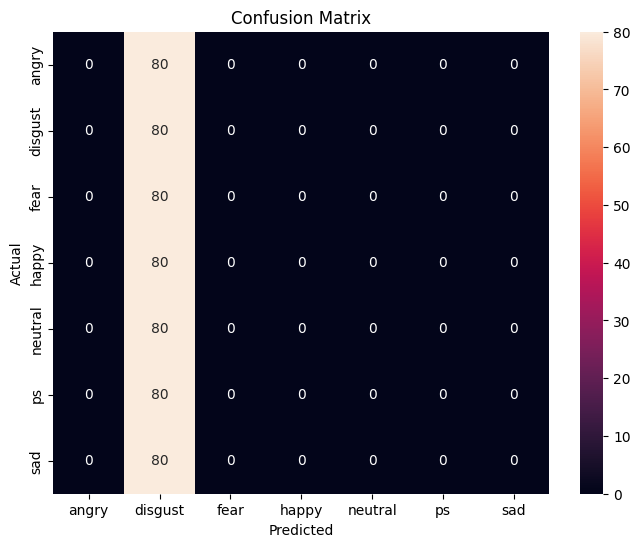

In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

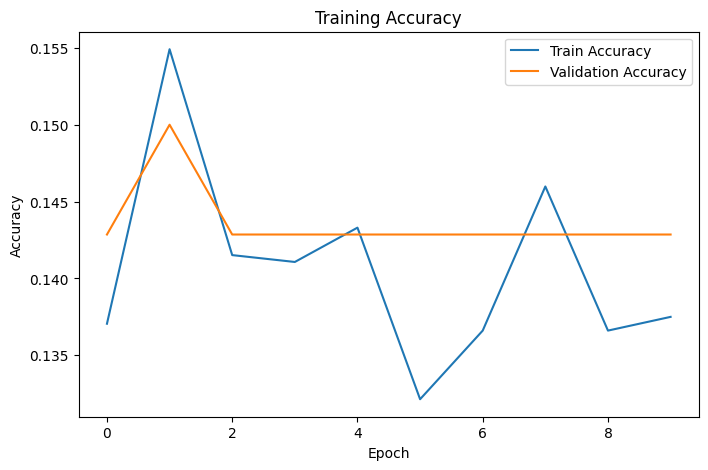

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.legend()

plt.show()

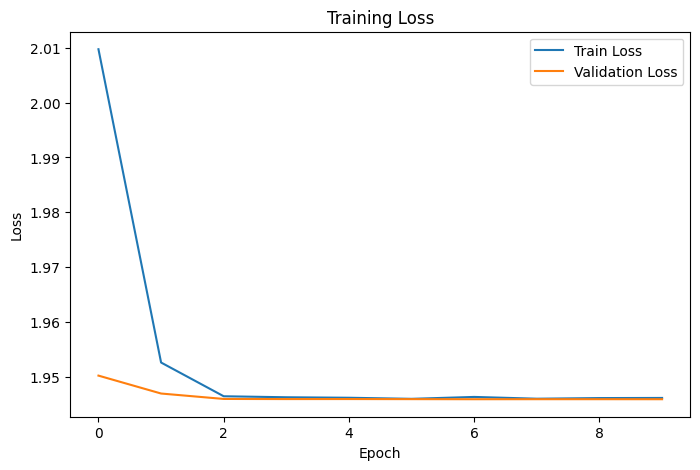

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.show()

In [17]:
model.save(
    "text_emotion_model.h5"
)

with open(
    "text_label_encoder.pkl",
    "wb"
) as f:

    pickle.dump(le, f)

print("Saved Successfully")

Saved Successfully


In [18]:
model = tf.keras.models.load_model(
    "text_emotion_model.h5"
)

with open(
    "text_label_encoder.pkl",
    "rb"
) as f:

    le = pickle.load(f)

print("Loaded Successfully")

Loaded Successfully


In [19]:
test_text = "Say the word dog"

In [20]:
emb = extract_bert_embedding(test_text)

emb = emb.reshape(1, -1)

prediction = model.predict(emb)

pred_class = np.argmax(
    prediction,
    axis=1
)

emotion = le.inverse_transform(
    pred_class
)[0]

print("Predicted Emotion:", emotion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Emotion: disgust
